## Imports & Data


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
import matplotlib.ticker as mticker


In [33]:
df1 = pd.read_csv('../data/BigNoPlug/17-03-high_001.csv', sep=';', decimal=',')
df2 = pd.read_csv('../data/BigNoPlug/17-03-high_002.csv', sep=';', decimal=',')
df3 = pd.read_csv('../data/BigNoPlug/17-03-high_003.csv', sep=';', decimal=',')
df4 = pd.read_csv('../data/BigNoPlug/17-03-high_004.csv', sep=';', decimal=',')
df5 = pd.read_csv('../data/BigNoPlug/17-03-high_005.csv', sep=';', decimal=',')
df6 = pd.read_csv('../data/BigNoPlug/17-03-high_006.csv', sep=';', decimal=',')
df7 = pd.read_csv('../data/BigNoPlug/17-03-high_007.csv', sep=';', decimal=',')
df8 = pd.read_csv('../data/BigNoPlug/17-03-high_008.csv', sep=';', decimal=',')
df9 = pd.read_csv('../data/BigNoPlug/17-03-high_009.csv', sep=';', decimal=',')
df10 = pd.read_csv('../data/BigNoPlug/17-03-high_010.csv', sep=';', decimal=',')
df11 = pd.read_csv('../data/BigNoPlug/17-03-high_011.csv', sep=';', decimal=',')
df12 = pd.read_csv('../data/BigNoPlug/17-03-high_012.csv', sep=';', decimal=',')
df13 = pd.read_csv('../data/BigNoPlug/17-03-high_013.csv', sep=';', decimal=',')
df14 = pd.read_csv('../data/BigNoPlug/17-03-high_014.csv', sep=';', decimal=',')
df15 = pd.read_csv('../data/BigNoPlug/17-03-high_015.csv', sep=';', decimal=',')
df16 = pd.read_csv('../data/BigNoPlug/17-03-high_016.csv', sep=';', decimal=',')
df17 = pd.read_csv('../data/BigNoPlug/17-03-high_017.csv', sep=';', decimal=',')
df18 = pd.read_csv('../data/BigNoPlug/17-03-high_018.csv', sep=';', decimal=',')

plug_df1 = pd.read_csv('../data/BigPlug/10-03-high_001.csv', sep=';', decimal=',')
plug_df2 = pd.read_csv('../data/BigPlug/10-03-high_002.csv', sep=';', decimal=',')
plug_df3 = pd.read_csv('../data/BigPlug/10-03-high_003.csv', sep=';', decimal=',')
plug_df4 = pd.read_csv('../data/BigPlug/10-03-high_004.csv', sep=';', decimal=',')
plug_df5 = pd.read_csv('../data/BigPlug/10-03-high_005.csv', sep=';', decimal=',')
plug_df6 = pd.read_csv('../data/BigPlug/10-03-high_006.csv', sep=';', decimal=',')
plug_df7 = pd.read_csv('../data/BigPlug/10-03-high_007.csv', sep=';', decimal=',')
plug_df8 = pd.read_csv('../data/BigPlug/10-03-high_008.csv', sep=';', decimal=',')
plug_df9 = pd.read_csv('../data/BigPlug/10-03-high_009.csv', sep=';', decimal=',')
plug_df10 = pd.read_csv('../data/BigPlug/10-03-high_010.csv', sep=';', decimal=',')
plug_df11 = pd.read_csv('../data/BigPlug/10-03-high_011.csv', sep=';', decimal=',')
plug_df12 = pd.read_csv('../data/BigPlug/10-03-high_012.csv', sep=';', decimal=',')
plug_df13 = pd.read_csv('../data/BigPlug/10-03-high_013.csv', sep=';', decimal=',')
plug_df14 = pd.read_csv('../data/BigPlug/10-03-high_014.csv', sep=';', decimal=',')

In [34]:
no_plug_dfs = [df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14, df15, df16, df17, df18]
plug_dfs = [plug_df4, plug_df5, plug_df6, plug_df7, plug_df8, plug_df9, plug_df10, plug_df11, plug_df12, plug_df13, plug_df14]

In [35]:
no_plug_df = pd.concat(no_plug_dfs, axis=0).reset_index(drop=True)
plug_df = pd.concat(plug_dfs, axis=0).reset_index(drop=True)

In [36]:
plug_df.describe()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
count,257430.000000,257430.000000,257430.000000,257430.000000,257430.000000,257430.000000,257430.000000,257430.000000
mean,337.054658,0.097917,0.107609,0.146490,-1.044579,-2.755419,-1.840857,25.306550
std,67.885388,0.003326,0.002469,0.001811,0.560331,0.147515,0.521072,0.483847
min,-1.423290,0.088401,0.091874,0.127540,-2.002714,-3.433069,-2.492141,24.657439
25%,347.189637,0.095856,0.105945,0.145363,-1.443540,-2.852948,-2.124629,24.946240
50%,358.882361,0.097432,0.107520,0.146466,-1.115386,-2.750574,-1.993374,25.179907
75%,366.614647,0.099217,0.109200,0.147752,-0.821361,-2.650825,-1.754492,25.500214
max,395.186385,0.127989,0.131252,0.168148,1.066179,-2.215078,0.613336,26.469011


In [37]:
for df in [no_plug_df, plug_df]:
    df['Time'] = pd.to_datetime(df['Time'].str.replace(',', '.'), format='%H:%M:%S.%f')
    df.set_index('Time', inplace=True)

In [38]:
df_n_resampled = no_plug_df.resample('100ms').mean().dropna()
df_p_resampled = plug_df.resample('100ms').mean().dropna()

In [39]:
for df in [df_n_resampled, df_p_resampled]:
    df['TS_Resistance'] = (df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']) / (df['Flow rate (Mean)']**2)
    
    df['Pump_to_TS_Resistance'] = (df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']) / (df['Flow rate (Mean)']**2)
    
    df['Total_System_DP'] = df['Pump outlet pressure (Mean)'] - df['TS outlet pressure (Mean)']

## Initial data visualization

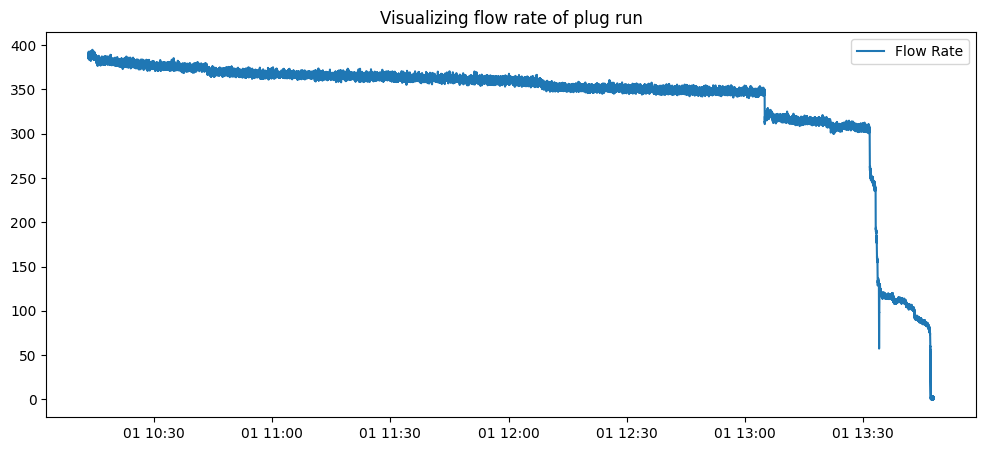

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(df_p_resampled['Flow rate (Mean)'], label='Flow Rate')
plt.title("Visualizing flow rate of plug run")
plt.legend()
plt.show()

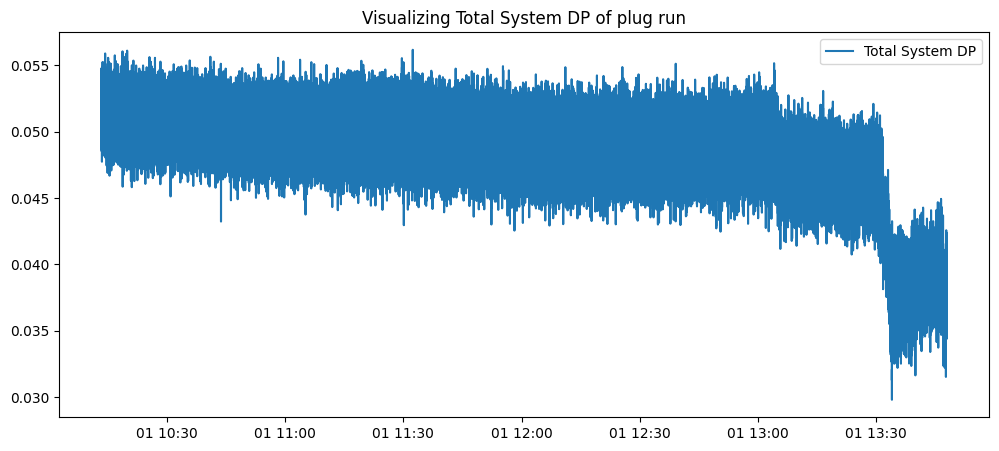

In [41]:
plt.figure(figsize=(12, 5))
plt.plot(df_p_resampled['Total_System_DP'], label='Total System DP')
plt.title("Visualizing Total System DP of plug run")
plt.legend()
plt.show()

## Machine learning

In [42]:
def extract_stl_features(df, period=120):
    stl_f = STL(df['Flow rate (Mean)'], period=period, trend=3001, robust=True).fit()
    df['f_trend'] = stl_f.trend

    stl_rts = STL(df['TS_Resistance'], period=period, trend=3001, robust=True).fit()
    df['ts_R_trend'] = stl_rts.trend
    
    stl_rup = STL(df['Pump_to_TS_Resistance'], period=period, trend=3001, robust=True).fit()
    df['pump_to_ts_R_trend'] = stl_rup.trend
    
    stl_total_p = STL(df['Total_System_DP'], period=period, trend=3001, robust=True).fit()
    df['total_p_resid'] = stl_total_p.resid
    df['global_volatility'] = df['total_p_resid'].rolling(window=period).std()
    
    return df.dropna()

df_n_final = extract_stl_features(df_n_resampled)
df_p_final = extract_stl_features(df_p_resampled)

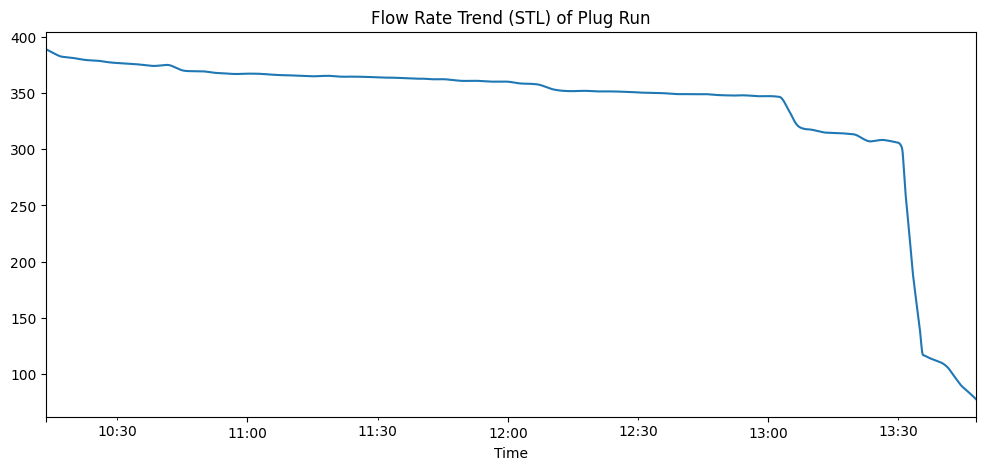

In [43]:
df_p_final['f_trend'].plot(figsize=(12, 5), title='Flow Rate Trend (STL) of Plug Run')
plt.show()

In [44]:
features = ['f_trend', 'ts_R_trend', 'pump_to_ts_R_trend', 'global_volatility']

scaler = StandardScaler()
X_train = scaler.fit_transform(df_n_final[features])

model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
model.fit(X_train)

IsolationForest(contamination=0.01, n_estimators=200, random_state=42)

/var/folders/mn/hmhwf_5919qf62p9d6fjr1cw0000gn/T/ipykernel_91593/2433978633.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p_final['anomaly_score'] = model.decision_function(X_test)


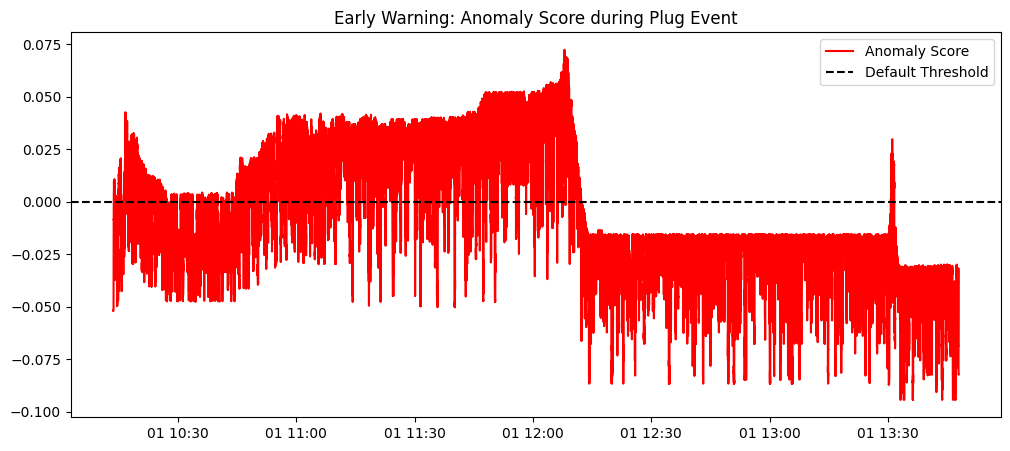

In [45]:
X_test = scaler.transform(df_p_final[features])

df_p_final['anomaly_score'] = model.decision_function(X_test)

plt.figure(figsize=(12, 5))
plt.plot(df_p_final['anomaly_score'], label='Anomaly Score', color='red')
plt.axhline(y=0, color='black', linestyle='--', label='Default Threshold')
plt.title("Early Warning: Anomaly Score during Plug Event")
plt.legend()
plt.show()

/var/folders/mn/hmhwf_5919qf62p9d6fjr1cw0000gn/T/ipykernel_91593/1096692454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p_final['smooth_score'] = df_p_final['anomaly_score'].rolling(window=1500).mean()
/var/folders/mn/hmhwf_5919qf62p9d6fjr1cw0000gn/T/ipykernel_91593/1096692454.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p_final['is_alert'] = (df_p_final['smooth_score'] < -0.00).astype(int)


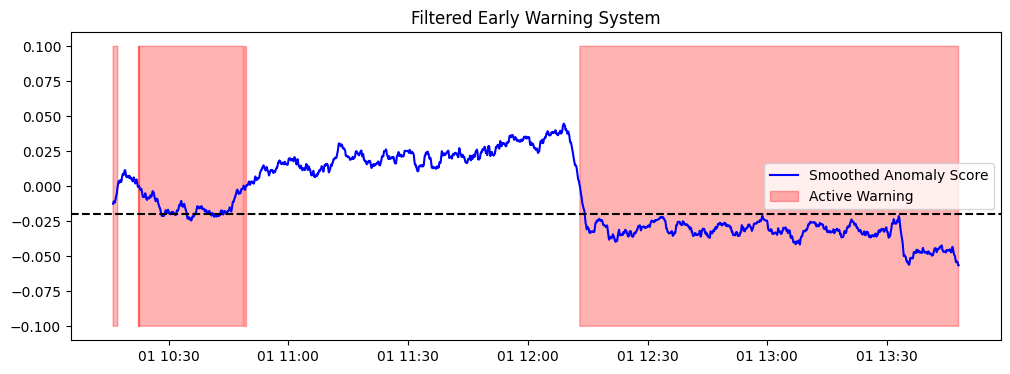

In [ ]:
df_p_final['smooth_score'] = df_p_final['anomaly_score'].rolling(window=1500).mean()

df_p_final['is_alert'] = (df_p_final['smooth_score'] < -0.02).astype(int)

plt.figure(figsize=(12, 4))
plt.plot(df_p_final['smooth_score'], color='blue', label='Smoothed Anomaly Score')
plt.fill_between(df_p_final.index, -0.1, 0.1, where=df_p_final['is_alert']==1, color='red', alpha=0.3, label='Active Warning')
plt.axhline(y=-0.02, color='black', linestyle='--')
plt.title("Filtered Early Warning System")
plt.legend()
plt.show()

In [47]:
correlation = df_p_final[features + ['anomaly_score']].corr()['anomaly_score'].sort_values()
print("Feature influence on Anomaly Score:")
print(correlation)

Feature influence on Anomaly Score:
pump_to_ts_R_trend   -0.346820
ts_R_trend           -0.293708
global_volatility    -0.089621
f_trend               0.448630
anomaly_score         1.000000
Name: anomaly_score, dtype: float64


## testing more

In [93]:
df1803 = pd.read_csv('../data/split/no_plug/1803.csv')
df2106_3 = pd.read_csv('../data/split/no_plug/2106-3.csv')
df2906_1 = pd.read_csv('../data/split/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/split/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/split/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/split/no_plug/0404.csv')
df1103 = pd.read_csv('../data/split/no_plug/1103.csv')
df2503 = pd.read_csv('../data/split/no_plug/2503.csv')

df0709 = pd.read_csv('../data/split/plug/0709.csv')
df2106_1 = pd.read_csv('../data/split/plug/2106-1.csv')
df2106_2 = pd.read_csv('../data/split/plug/2106-2.csv')
df2401_1 = pd.read_csv('../data/split/plug/2401-1.csv')
df2401_2 = pd.read_csv('../data/split/plug/2401-2.csv')
df2906_2 = pd.read_csv('../data/split/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/split/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/split/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/split/plug/3006-3.csv')
df0612_1 = pd.read_csv('../data/split/plug/0612-1.csv')
df0612_2 = pd.read_csv('../data/split/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/split/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/split/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/split/plug/0707-2.csv')
df0707_3 = pd.read_csv('../data/split/plug/0707-3.csv')
df0707_4 = pd.read_csv('../data/split/plug/0707-4.csv')
df1310_1 = pd.read_csv('../data/split/plug/1310-1.csv')
df1310_2 = pd.read_csv('../data/split/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/split/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/split/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/split/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/split/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/split/plug/1407-4.csv')
df1503 = pd.read_csv('../data/split/plug/1503.csv')
df1811 = pd.read_csv('../data/split/plug/1811.csv')
df2701 = pd.read_csv('../data/split/plug/2701.csv')

In [94]:
dfs = [df1803, df2106_3, df2906_1, df3006_1, df3006_2, df0404, df1103, df2503, df0709, df2106_1, df2106_2, df2401_1, df2401_2, df2906_2, df2906_3, df2906_4, df3006_3, df0612_1, df0612_2, df0612_3, df0707_1, df0707_2, df0707_3, df0707_4, df1310_1, df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

In [95]:
feat_dfs = []
for df in dfs:
    df.drop(columns = ['elapsed_runtime_m', 'elapsed_runtime_s', 'reading_interval_s'], inplace=True)
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df["Time"] = df["Time"].dt.strftime("%H:%M:%S.%f").str[:-3]
    df['TS_Resistance'] = (df['TS inlet pressure (Mean)'] - df['TS outlet pressure (Mean)']) / (df['Flow rate (Mean)']**2)
    
    df['Pump_to_TS_Resistance'] = (df['Pump outlet pressure (Mean)'] - df['TS inlet pressure (Mean)']) / (df['Flow rate (Mean)']**2)
    
    df['Total_System_DP'] = df['Pump outlet pressure (Mean)'] - df['TS outlet pressure (Mean)']
    feat_dfs.append(df)

In [96]:
master_column_order = [
    'Time',
    'Flow rate (Mean)',
    'TS outlet pressure (Mean)',
    'TS inlet pressure (Mean)',
    'Pump outlet pressure (Mean)',
    'Temperature TS outlet (Mean)',
    'Tank temperature (Mean)',
    'Temperature TS inlet (Mean)',
    'Bypass temperature (Mean)',
    'TS_Resistance',
    'Pump_to_TS_Resistance',
    'Total_System_DP'
]

In [97]:
ordered_dfs = []
for df in feat_dfs:
    df_reordered = df[master_column_order].copy()
    df_reordered = df_reordered.sort_values('Time').reset_index(drop=True)
    ordered_dfs.append(df_reordered)

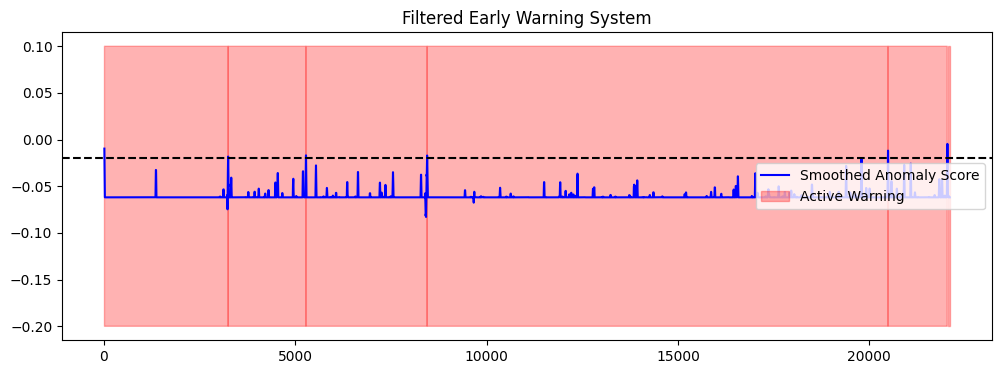

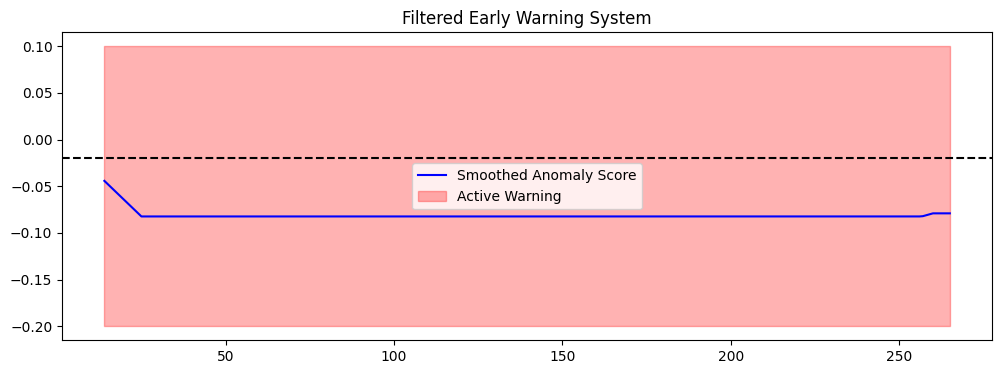

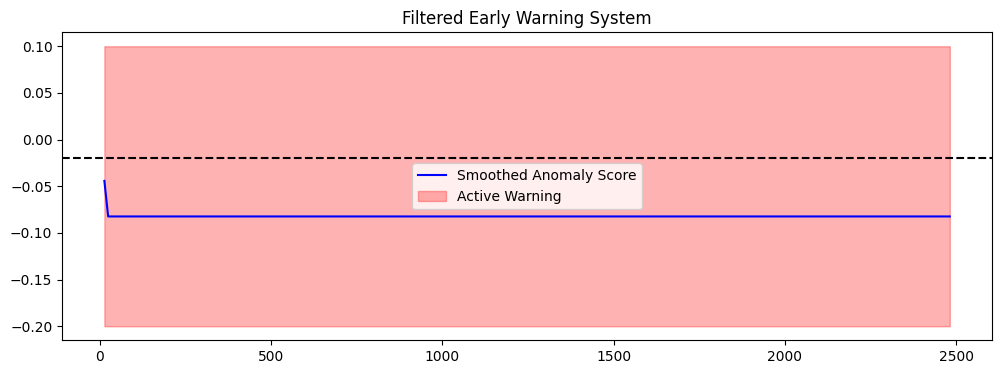

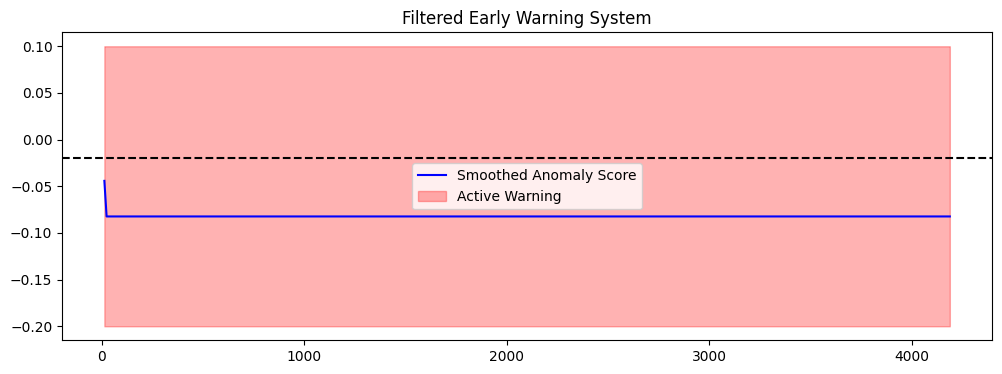

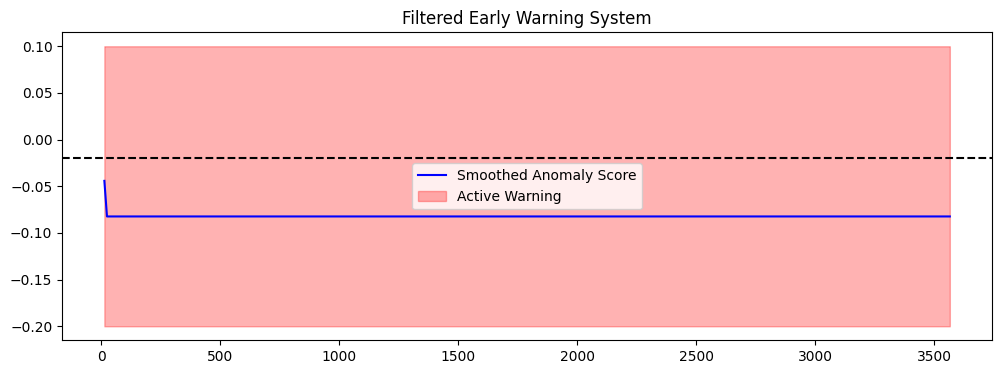

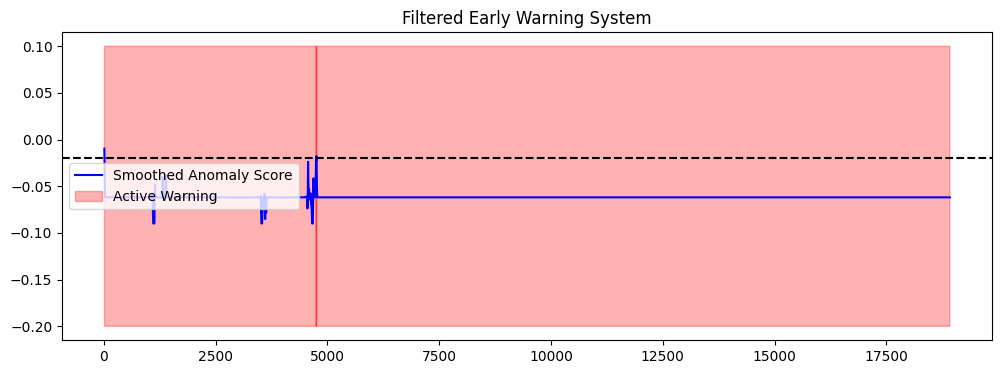

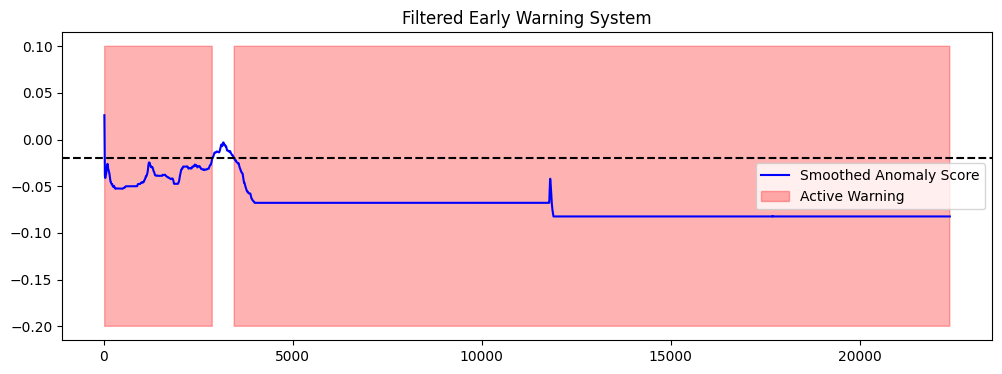

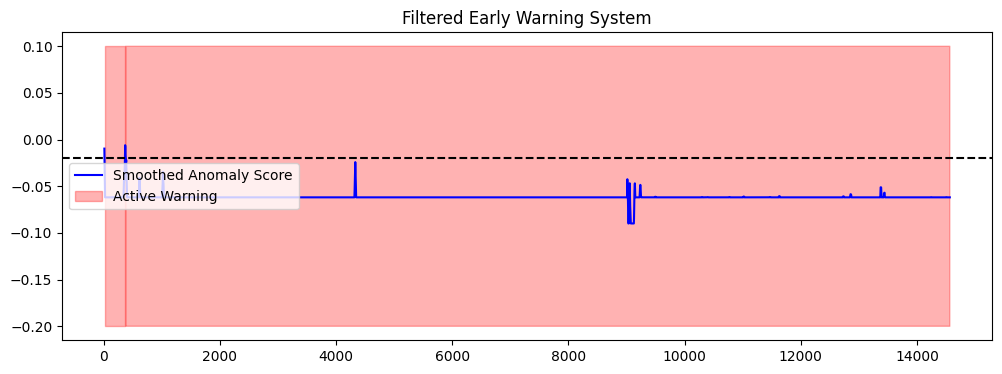

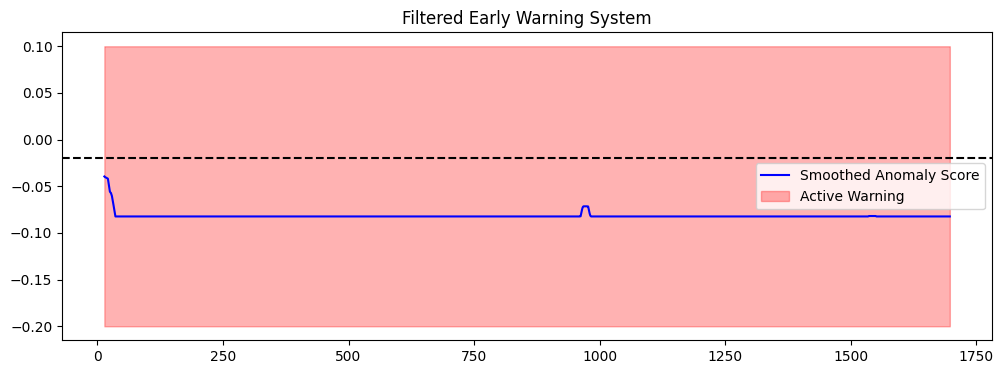

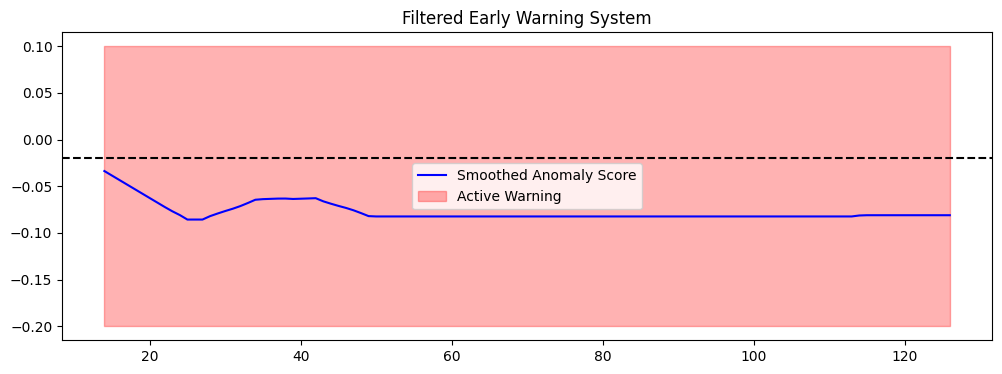

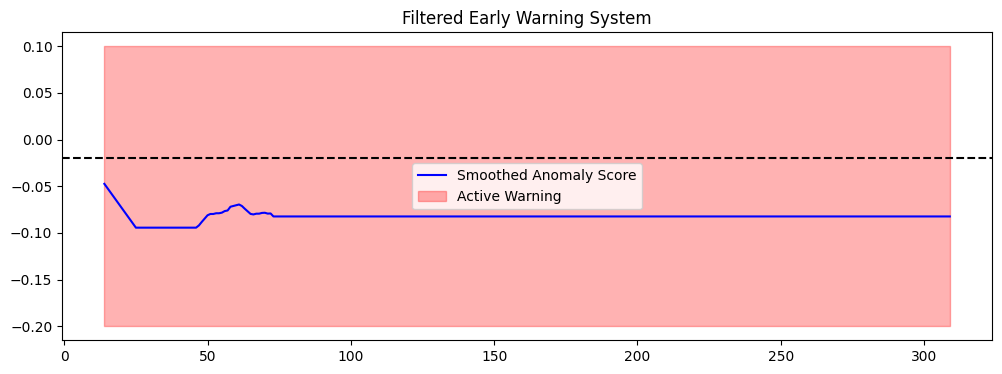

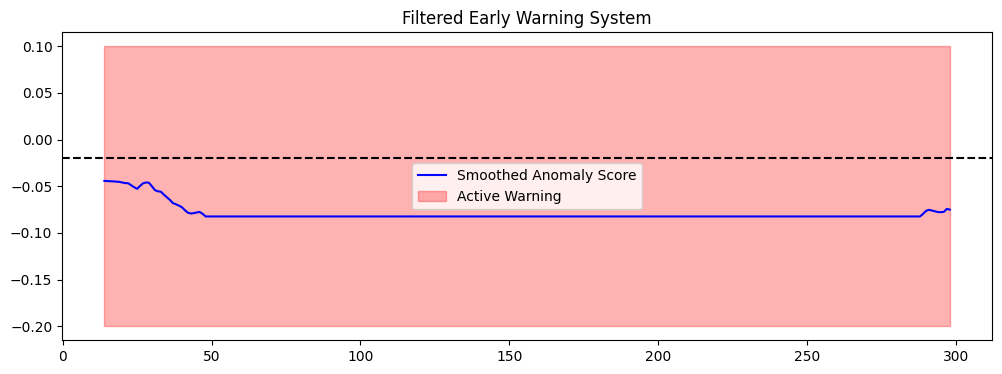

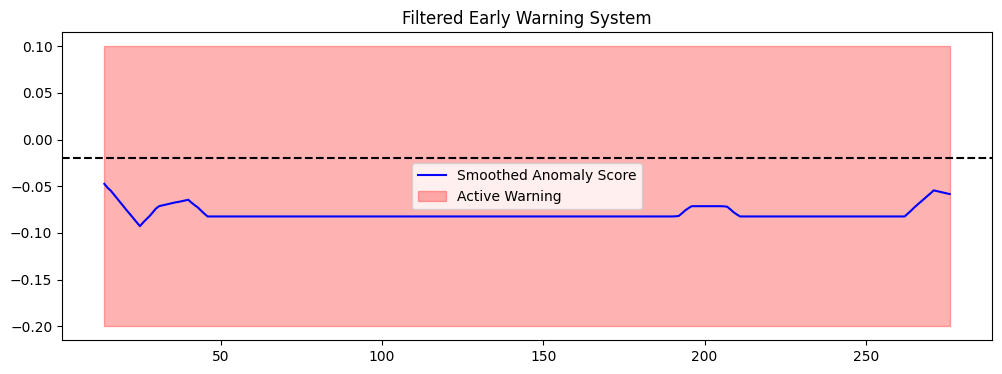

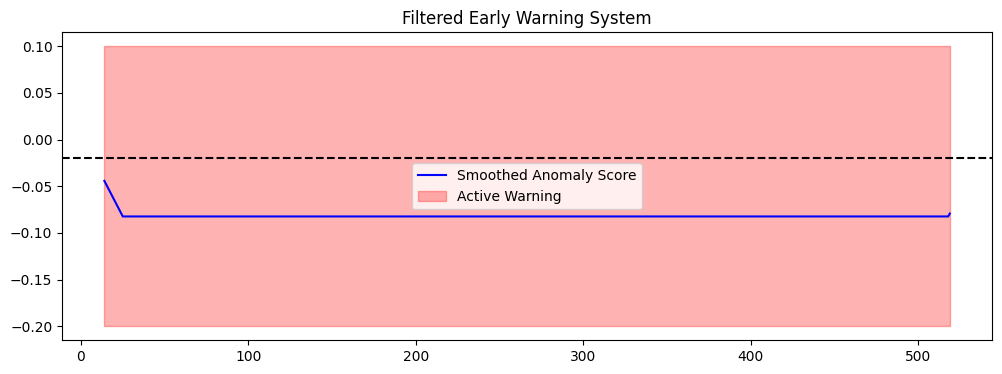

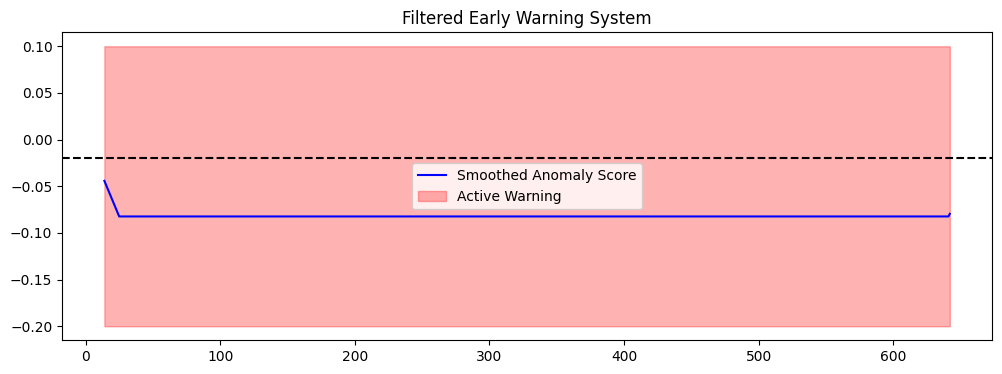

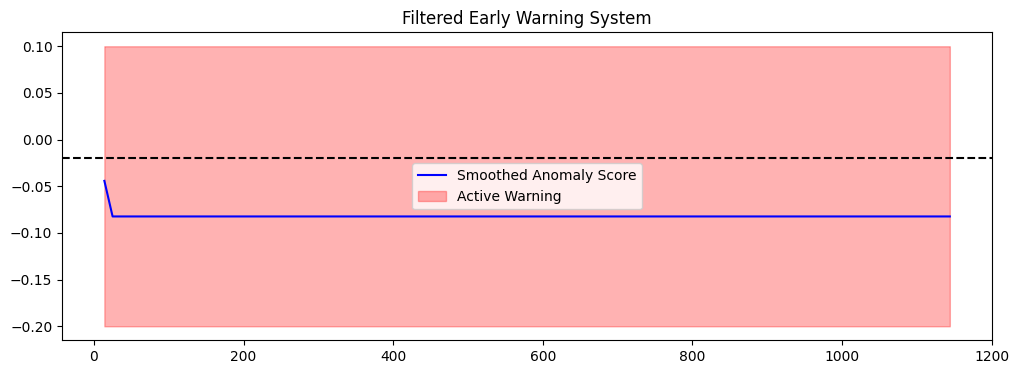

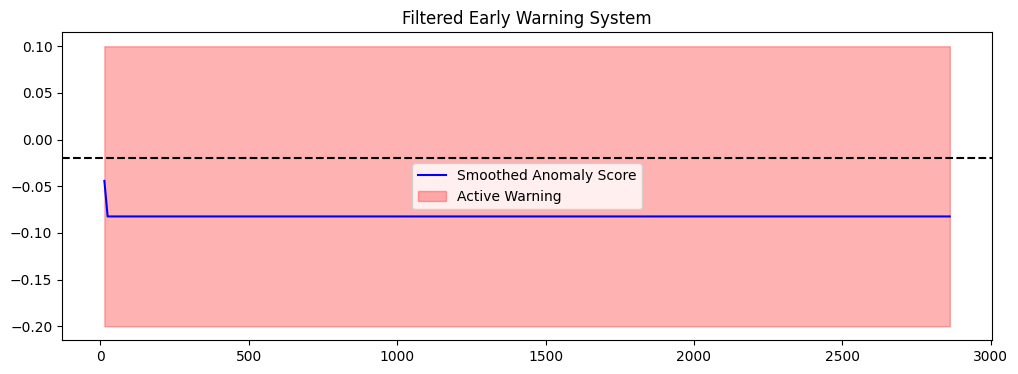

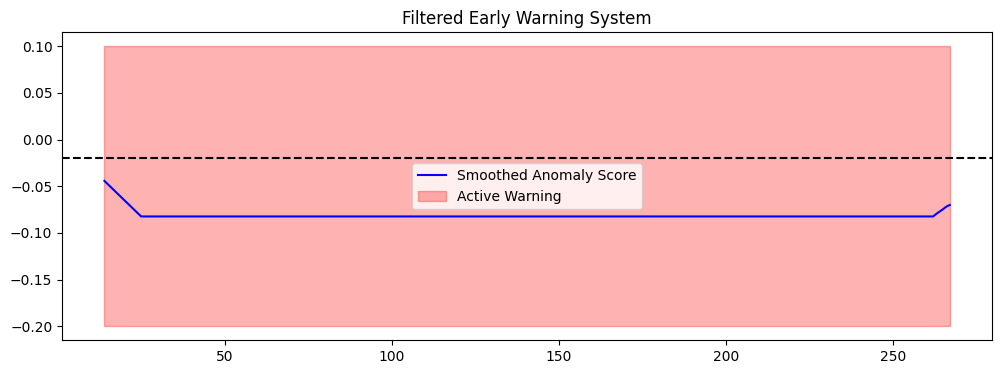

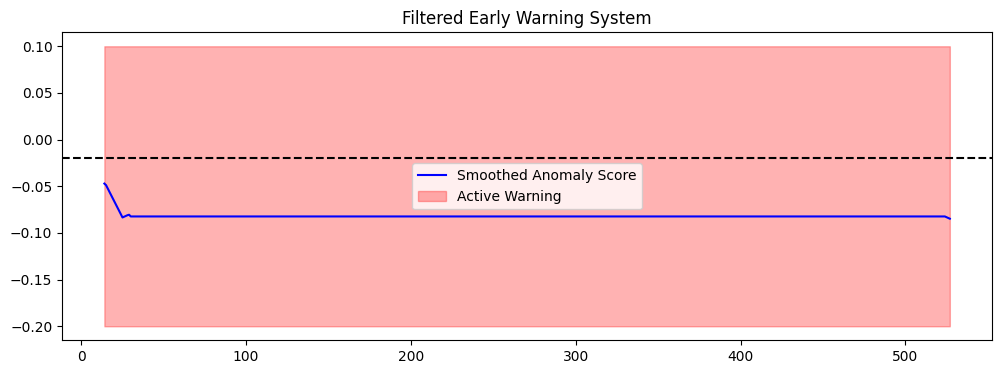

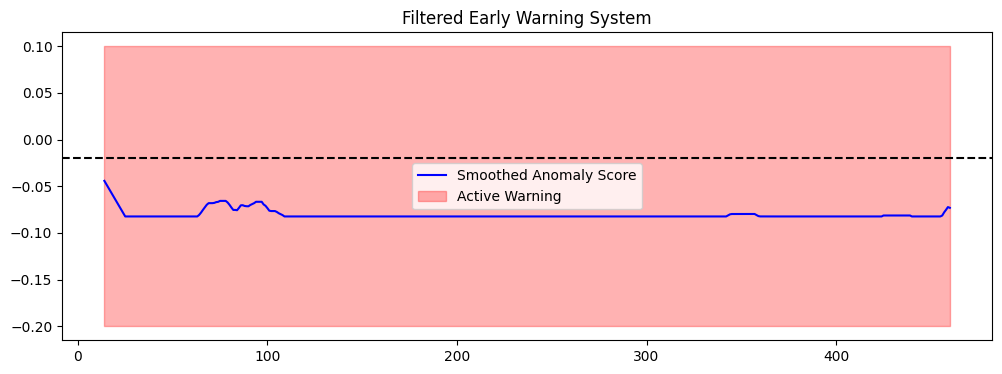

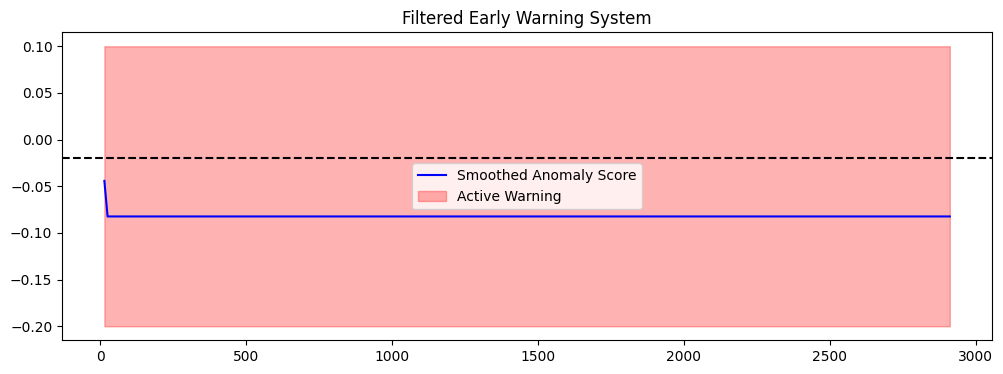

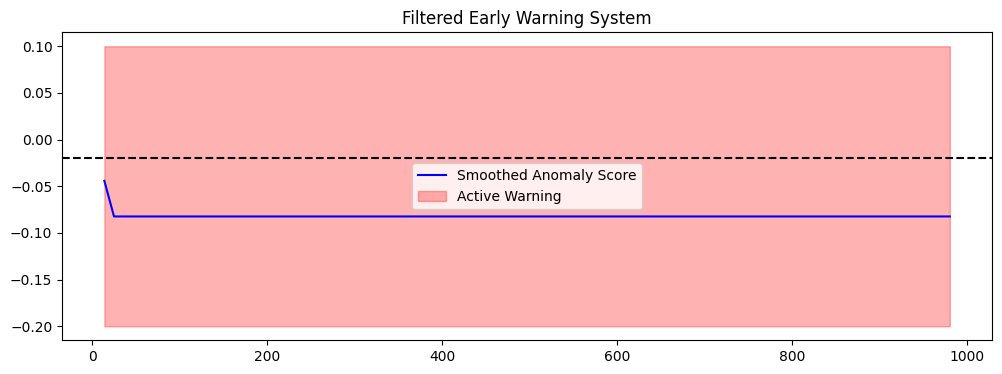

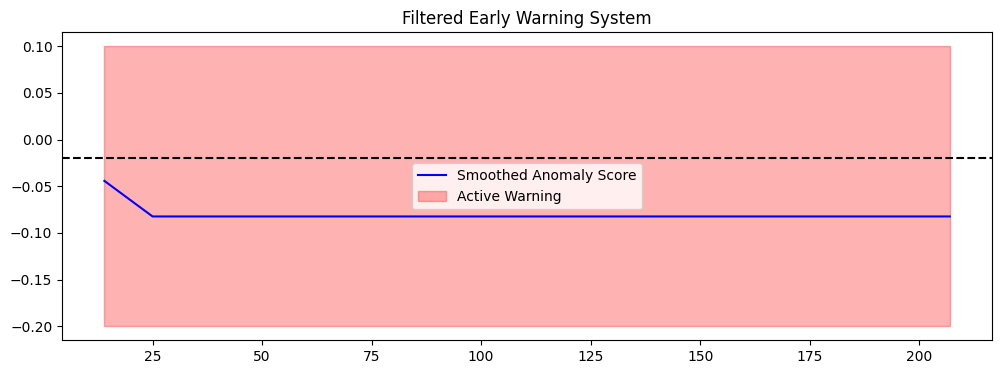

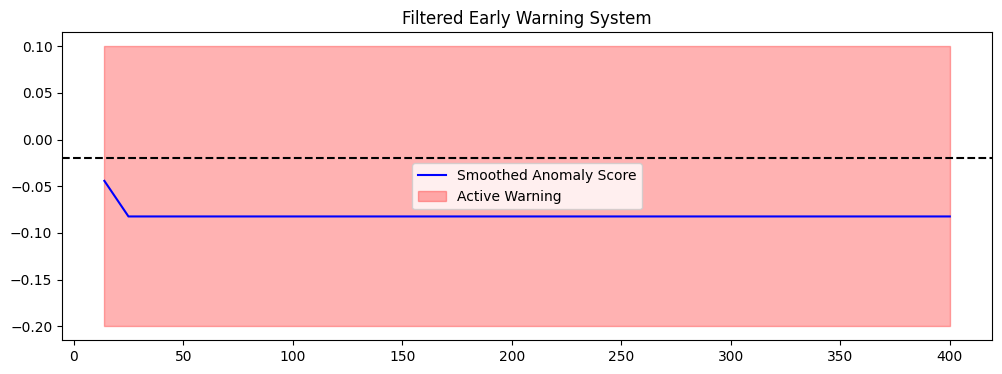

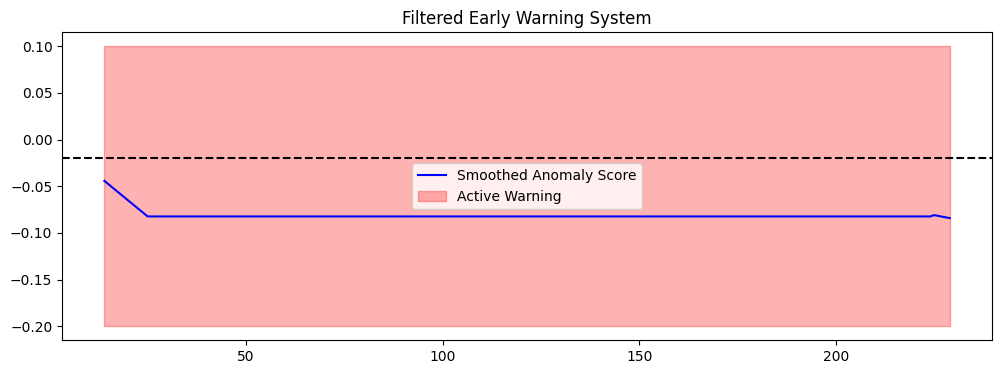

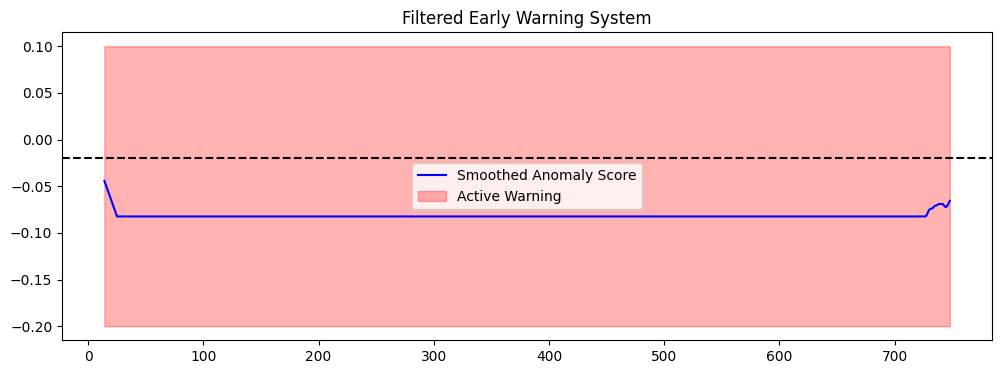

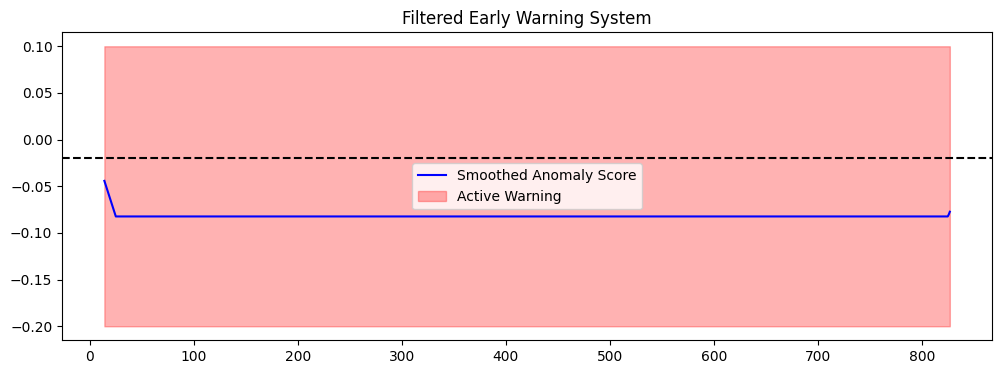

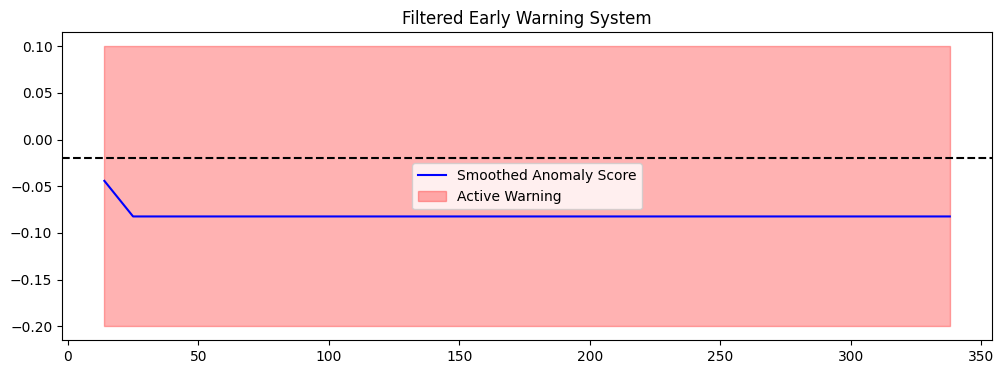

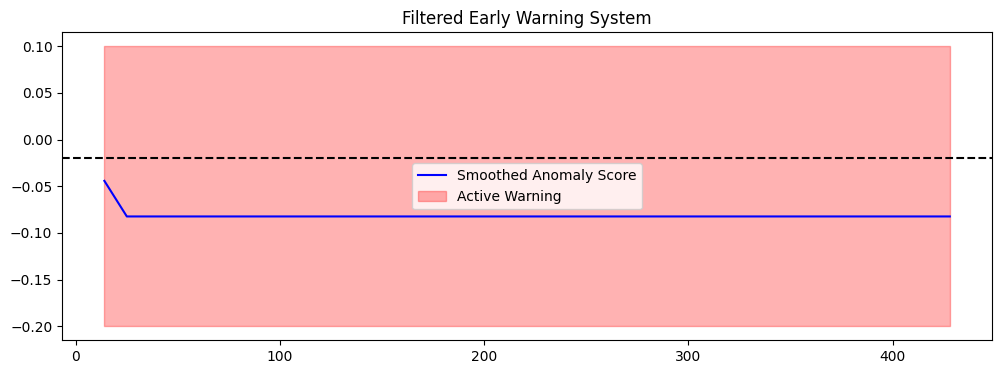

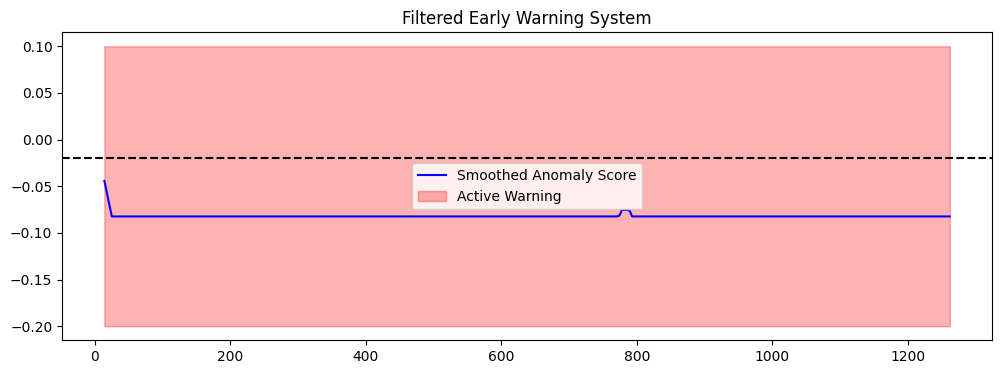

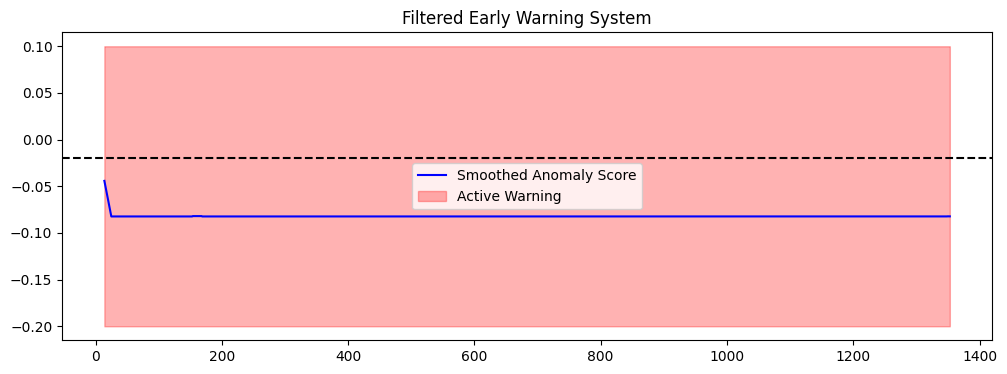

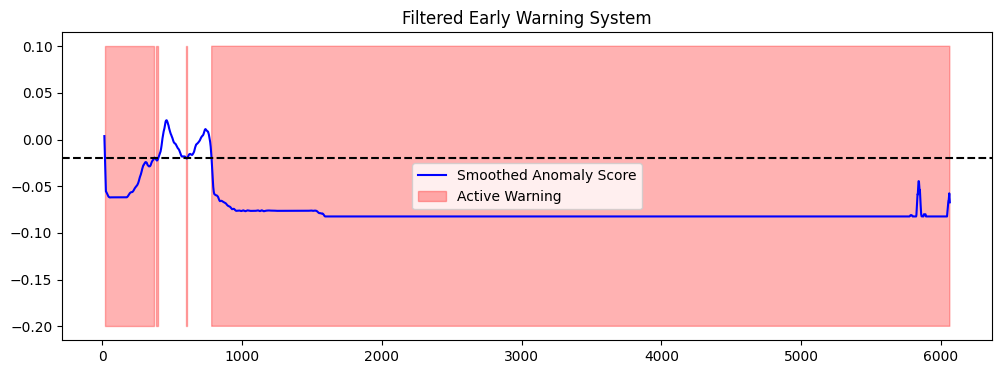

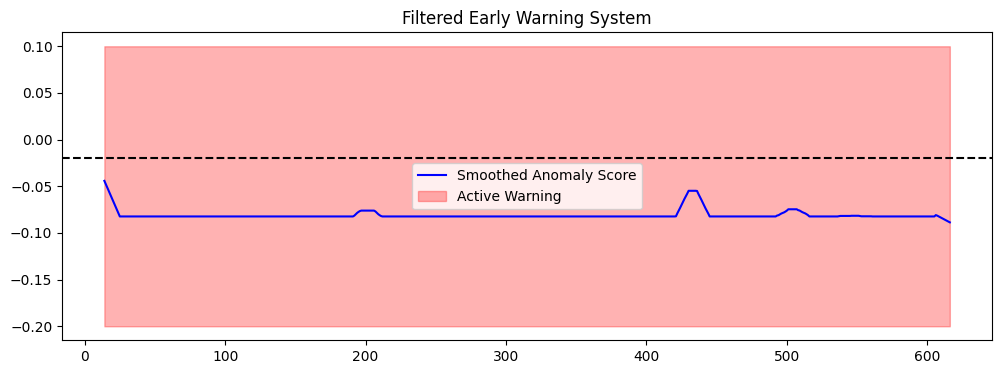

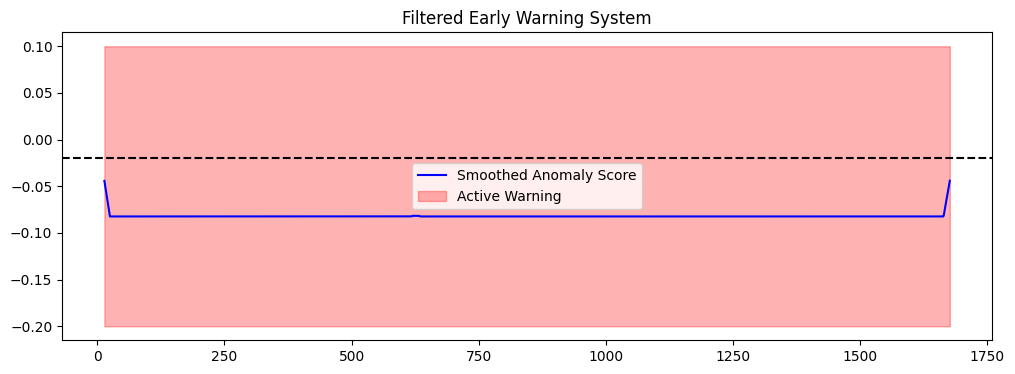

In [ ]:

for df in ordered_dfs:

    stl_f = STL(df['Flow rate (Mean)'], period=12, trend=301, robust=True).fit()
    df['f_trend'] = stl_f.trend

    stl_rts = STL(df['TS_Resistance'], period=12, trend=301, robust=True).fit()
    df['ts_R_trend'] = stl_rts.trend

    stl_rup = STL(df['Pump_to_TS_Resistance'], period=12, trend=301, robust=True).fit()
    df['pump_to_ts_R_trend'] = stl_rup.trend

    stl_total_p = STL(df['Total_System_DP'], period=12, trend=301, robust=True).fit()
    df['total_p_resid'] = stl_total_p.resid
    df['global_volatility'] = df['total_p_resid'].rolling(window=12).std()


    X_test = scaler.transform(df[features])

    df['anomaly_score'] = model.decision_function(X_test)

    df['smooth_score'] = df['anomaly_score'].rolling(window=15).mean()

    df['is_alert'] = (df['smooth_score'] < -0.02).astype(int)

    plt.figure(figsize=(12, 4))
    plt.plot(df['smooth_score'], color='blue', label='Smoothed Anomaly Score')
    plt.fill_between(df.index, -0.2, 0.1, where=df['is_alert']==1, color='red', alpha=0.3, label='Active Warning')
    plt.axhline(y=-0.02, color='black', linestyle='--')
    plt.title("Filtered Early Warning System")
    plt.legend()
    plt.show()
    
